In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("healthcare_dataset (1).csv")

In [5]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [6]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [7]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [8]:
df['No_of_days_stayed'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

In [10]:
df["No_of_days_stayed"].head()

,No_of_days_stayed
0,2
1,6
2,15
3,30
4,20


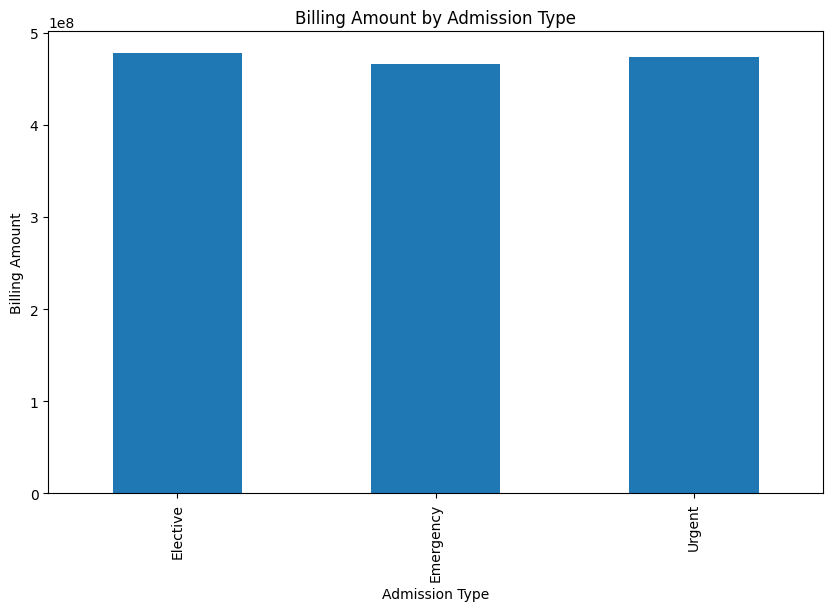

In [28]:
billing = df.groupby('Admission Type')['Billing Amount'].sum()

billing.plot(
    kind="bar",
    figsize=(10,6),
    stacked=True
)
plt.title("Billing Amount by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Billing Amount")
plt.show()

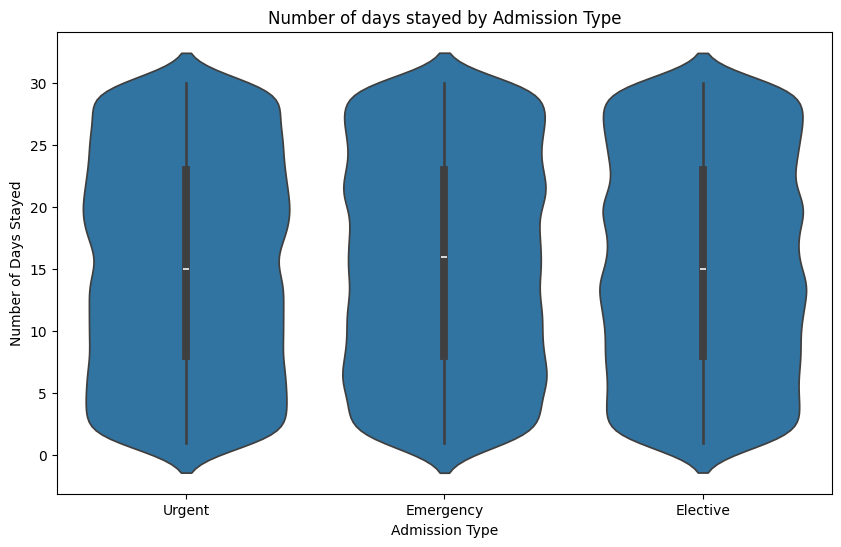

In [13]:
plt.figure(figsize=(10,6))
sns.violinplot(
    data=df,
    x="Admission Type",
    y="No_of_days_stayed"
)
plt.title("Number of days stayed by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Days Stayed")
plt.show()

In [15]:
df['Admission Month'] = df['Date of Admission'].dt.month
df['Admission Month']

,Admission Month
0,1
1,8
2,9
3,11
4,9
...,...
55495,8
55496,1
55497,7
55498,5


In [16]:
monthly_admissions = df.groupby('Admission Month').size()
monthly_admissions

,0
Admission Month,
1,4692
2,4255
3,4672
4,4518
5,4599
6,4699
7,4812
8,4832
9,4546


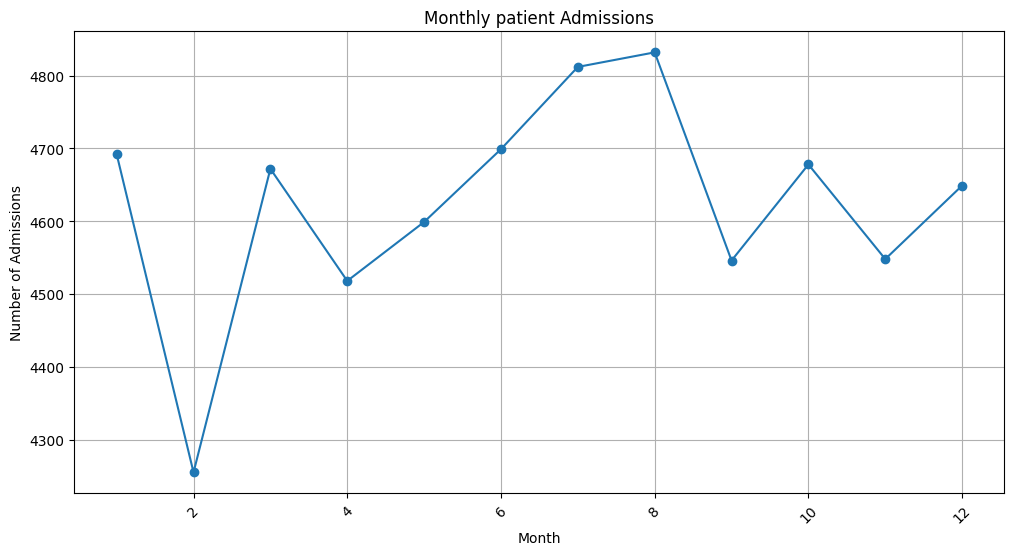

In [22]:
plt.figure(figsize=(12,6))
monthly_admissions.plot(
    kind="line", marker="o"
)
plt.title("Monthly patient Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.grid()

In [25]:
correlation_matrix = df[["Age","No_of_days_stayed", "Billing Amount"]].corr()
correlation_matrix

,Age,No_of_days_stayed,Billing Amount
Age,1.000000,0.008220,-0.003832
No_of_days_stayed,0.008220,1.000000,-0.005602
Billing Amount,-0.003832,-0.005602,1.000000


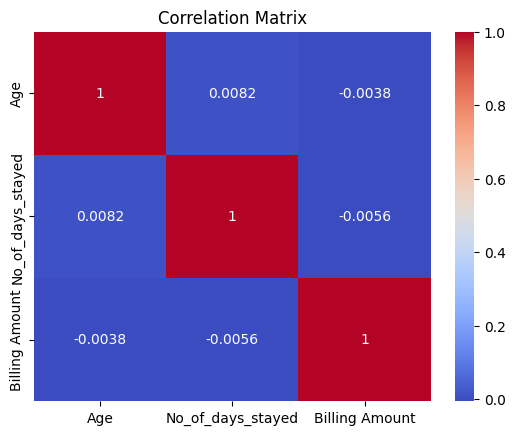

In [26]:
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()